# 📧 Phishing Email Classification Pipeline

## Overview
This notebook implements an end-to-end machine learning pipeline for detecting phishing emails.
The system analyzes the email body to classify messages as legitimate (safe) or phishing.

## 🎯 Objectives
- **Data Loading**: Load and merge multiple email datasets (Enron.csv, Ling.csv)
- **Data Cleaning**: Handle missing values, remove duplicates, normalize email text
- **Exploratory Analysis**: Generate word clouds showing distinctive terms for each class
- **Feature Engineering**: Transform email body content using TF-IDF vectorization
- **Model Training**: Train SVM with Sigmoid Calibration
- **Model Evaluation**: Measure performance using cross-validation, test metrics, and stability analysis
- **Model Persistence**: Save the trained model and vectorizer

## 📊 Dataset
- **Sources**: Enron.csv, Ling.csv
- **Features**: Email body text (subject column excluded)
- **Labels**: Binary (0 = Safe, 1 = Phishing)
- **Preprocessing**: Text cleaning, normalization, duplicate removal after merging

## 🤖 Machine Learning Approach

### Email Text Preprocessing
- Convert text to lowercase
- Normalize whitespace and remove underscores
- Remove pure numbers
- Remove empty emails
- Deduplicate merged dataset

### Feature Extraction
**TF-IDF Vectorization** converts the email body into numerical features for machine learning models.

**Configuration:**
- **Max Features**: 10,000
- **N-grams**: Unigrams, Bigrams, Trigrams (1-3)
- **Min DF**: 2 (must appear in at least 2 documents)
- **Max DF**: 0.95 (exclude terms in >95% of documents)
- **Special Patterns**: URLs, email addresses

### Model Architecture
**Linear SVM with Sigmoid Calibration (CalibratedClassifierCV)**
- Base classifier: LinearSVC with 1000 max iterations
- Calibration: 5-fold cross-validation with sigmoid method
- Provides probability estimates for better classification decisions

### Evaluation Strategy
- **Training/Test Split**: 80/20 stratified split
- **10-fold Stratified Cross-Validation** on training data
- **Stability Analysis**: Testing across 10 different random splits
- **Metrics**: Accuracy, Precision, Recall, F1, ROC-AUC, Specificity
- **Visualizations**: Confusion matrix, classification report heatmap, word clouds

## 📦 Output Artifacts
- **tfidf_vectorizer.pkl** - Trained TF-IDF vectorizer
- **model.pkl** - Trained SVM classifier
- **wordclouds_comparison.png** - Distinctive terms visualization
- **model_evaluation_metrics.png** - Performance metrics visualization

## 🔍 Key Features
- **Distinctive Term Analysis**: Identifies words unique to safe vs phishing emails
- **High Performance**: Achieves ~98% accuracy with consistent results
- **Speed Benchmarking**: Tracks training and prediction time
- **Production Ready**: Saves model artifacts for deployment

In [1]:
import pandas as pd
import time
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm 
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, average_precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load both datasets
print("📁 Loading datasets...")
try:
    df_enron = pd.read_csv("Enron.csv", engine="python", on_bad_lines="skip")
    df_ling = pd.read_csv("Ling.csv", engine="python", on_bad_lines="skip")
    print(f"✅ Loaded Enron.csv → {df_enron.shape}")
    print(f"✅ Loaded Ling.csv → {df_ling.shape}")
except Exception as e:
    print(f"❌ Error loading datasets: {e}")
    raise

# Select only 'body' and 'label' columns from both datasets
print("\n🔧 Selecting body and label columns...")
enron_clean = df_enron[['body', 'label']].copy()
ling_clean = df_ling[['body', 'label']].copy()

# Rename for consistency
enron_clean.columns = ['email_text', 'label']
ling_clean.columns = ['email_text', 'label']

# Merge the datasets
print("\n🔗 Merging datasets...")
clean_df = pd.concat([enron_clean, ling_clean], ignore_index=True)
print(f"✅ Combined dataset shape: {clean_df.shape}")

print(f"\n🏷️ Label distribution after merge:")
print(clean_df['label'].value_counts())

# Convert labels to integers (they should already be 0 or 1)
clean_df['label'] = pd.to_numeric(clean_df['label'], errors='coerce')
clean_df = clean_df.dropna(subset=['label'])
clean_df['label'] = clean_df['label'].astype(int)

# Verify labels are only 0 and 1
unique_labels = clean_df['label'].unique()
print(f"\n✅ Unique labels in dataset: {sorted(unique_labels)}")
if not set(unique_labels).issubset({0, 1}):
    print(f"⚠️ WARNING: Found unexpected labels: {unique_labels}")

📁 Loading datasets...
✅ Loaded Enron.csv → (31326, 3)
✅ Loaded Ling.csv → (2859, 3)

🔧 Selecting body and label columns...

🔗 Merging datasets...
✅ Combined dataset shape: (34185, 2)

🏷️ Label distribution after merge:
label
0                                                                                                                                                                                                                                                                                                                                                                                             15787
1                                                                                                                                                                                                                                                                                                                                                                                             13976

In [3]:
# Remove duplicates
initial_count = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["email_text"], keep="first")
final_count = len(clean_df)

print(f"🗑️ Removed {initial_count - final_count} duplicate emails")
print(f"📊 Final cleaned dataset: {clean_df.shape}")

clean_df = clean_df.reset_index(drop=True)

print(f"\n📊 Class distribution:")
print(clean_df['label'].value_counts())

print("\n✅ Cleaned dataset ready for model training")

print("\n" + "="*80)
print("📋 CLEANED DATASET PREVIEW")
print("="*80)

for idx in range(min(3, len(clean_df))):
    row = clean_df.iloc[idx]
    print(f"\n[Email {idx+1}]")
    print(f"  Label: {row['label']} ({'safe' if row['label'] == 0 else 'phishing'})")  # Inline display
    print(f"  Length: {len(row['email_text'])} characters")
    print(f"  Text: {row['email_text'][:200]}...")
    print("-" * 80)

if len(clean_df[clean_df["label"] == 0]) > 0:
    print("\n🟢 SAFE EMAIL EXAMPLE:")
    sample = clean_df[clean_df["label"] == 0].iloc[0]
    print(sample['email_text'][:500], "\n")

if len(clean_df[clean_df["label"] == 1]) > 0:
    print("\n🔴 PHISHING EMAIL EXAMPLE:")
    sample = clean_df[clean_df["label"] == 1].iloc[0]
    print(sample['email_text'][:500], "\n")

🗑️ Removed 0 duplicate emails
📊 Final cleaned dataset: (32622, 2)

📊 Class distribution:
label
0    18188
1    14434
Name: count, dtype: int64

✅ Cleaned dataset ready for model training

📋 CLEANED DATASET PREVIEW

[Email 1]
  Label: 0 (safe)
  Length: 58 characters
  Text: ( see attached file : hplno 525 . xls )
- hplno 525 . xls...
--------------------------------------------------------------------------------

[Email 2]
  Label: 0 (safe)
  Length: 1608 characters
  Text: - - - - - - - - - - - - - - - - - - - - - - forwarded by sabrae zajac / hou / ect on 05 / 30 / 2001 12 : 07 pm - - - - - - - - - - - - - - - - - - - - - - - - - - -
enron capital & trade resources co...
--------------------------------------------------------------------------------

[Email 3]
  Label: 0 (safe)
  Length: 171 characters
  Text: estimated actuals
march 30 , 2001
no flow
march 31 , 2001
no flow
april 1 , 2001
teco tap 35 . 000
when i receive the actuals from duke i will forward them to you ....
------

✅ Loaded mask images
🔍 Extracting class-specific terms...

✅ Top Safe Email Terms:
   enron: 42.7080
   ect: 15.9721
   hou ect: 8.1737
   ect ect: 6.7046
   vince: 5.5130
   enron com: 2.7221
   xls: 2.5528
   kaminski: 2.4643
   hpl: 1.7653
   vince kaminski: 1.7481
   schedules: 1.6609
   mmbtu: 1.3704
   louise: 1.2535
   enron enron: 1.2295
   hou: 1.0042

✅ Top Phishing Email Terms:
   viagra: 2.0731
   pills: 1.0582
   adobe: 0.8478
   save: 0.4944
   click here: 0.4864
   http: 0.2876
   your: 0.2600
   money: 0.2070
   here: 0.1978
   remove: 0.1861
   click: 0.1858
   stop: 0.1854
   statements: 0.1813
   online: 0.1649
   professional: 0.1555

✅ Saved: ../pictures/wordclouds_comparison.png


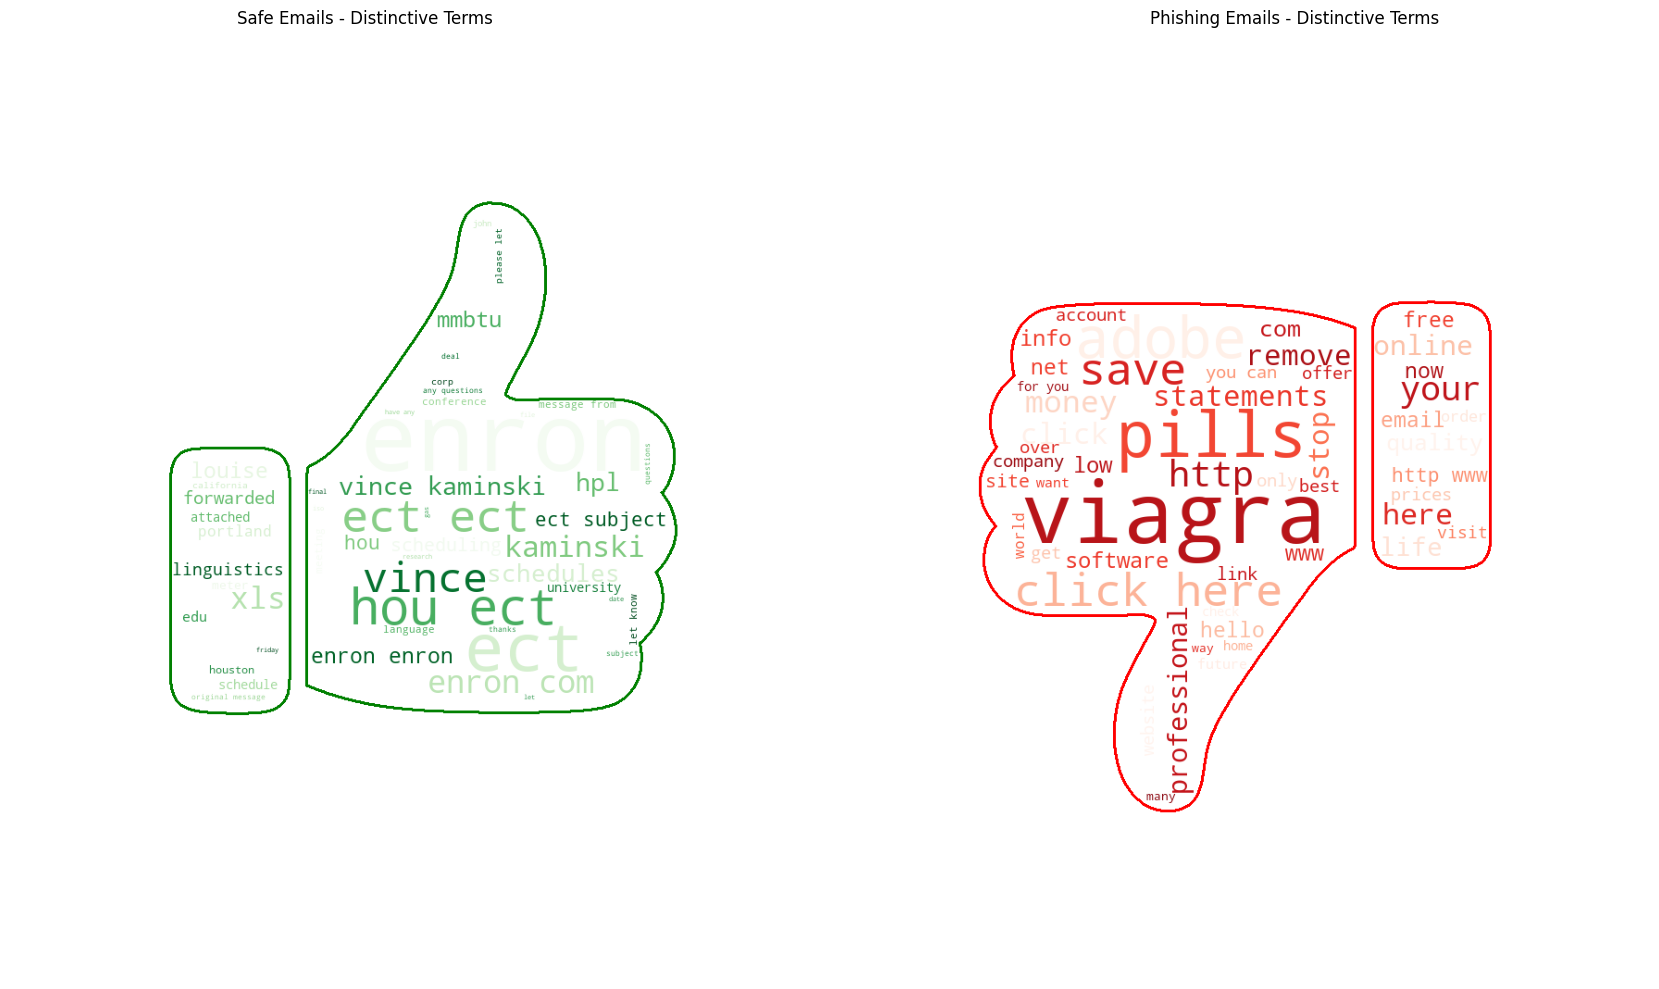

In [4]:
def load_mask(path):
    """Load and convert mask image."""
    mask = Image.open(path).convert("L")
    mask = mask.point(lambda x: 0 if x < 128 else 255, "L")
    return np.array(mask)

try:
    mask_up = load_mask("../pictures/thumbs-up.png")
    mask_down = load_mask("../pictures/thumbs-down.png")
    use_masks = True
    print("✅ Loaded mask images")
except:
    print("⚠️ Mask images missing → generating word clouds without masks")
    use_masks = False
    mask_up = None
    mask_down = None

print("🔍 Extracting class-specific terms...\n")

# Extended stopwords to filter common words
extended_stopwords = {
    'the', 'to', 'of', 'and', 'in', 'for', 'is', 'on', 'that', 'this', 
    'with', 'are', 'from', 'will', 'be', 'by', 'at', 'or', 'an', 'as',
    'was', 'has', 'have', 'had', 'been', 'can', 'may', 'would', 'could',
    'it', 'its', 'they', 'their', 'them', 'we', 'our', 'us', 'which',
    'all', 'any', 'some', 'more', 'not', 'but', 'if', 'when', 'than'
}

# Separate texts by class
safe_emails = clean_df[clean_df["label"]==0]["email_text"].values
phishing_emails = clean_df[clean_df["label"]==1]["email_text"].values

# Create vectorizer
tfidf_analyzer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    min_df=10,  # Must appear in at least 10 documents
    token_pattern=r'\b[a-zA-Z]{3,}\b'
)

# Fit on all data
tfidf_analyzer.fit(clean_df["email_text"].values)

# Transform each class separately
safe_vec = tfidf_analyzer.transform(safe_emails)
phishing_vec = tfidf_analyzer.transform(phishing_emails)

# Get mean TF-IDF scores for each class
safe_mean = safe_vec.mean(axis=0).A1
phishing_mean = phishing_vec.mean(axis=0).A1

feature_names = tfidf_analyzer.get_feature_names_out()

# Calculate ratio: how much more it appears in one class vs the other
# Add small constant to avoid division by zero
epsilon = 0.0001

safe_ratio = safe_mean / (phishing_mean + epsilon)
phishing_ratio = phishing_mean / (safe_mean + epsilon)

# Filter and rank
safe_distinctive = {}
phishing_distinctive = {}

for i, term in enumerate(feature_names):
    # Skip if in stopwords or not alphabetic
    if term.lower() in extended_stopwords or not term.replace(' ', '').isalpha():
        continue
    
    # Only include if it appears meaningfully in the class
    if safe_mean[i] > 0.01 and safe_ratio[i] > 2.0:  # 2x more in safe
        safe_distinctive[term] = safe_mean[i] * safe_ratio[i]  # Weight by both frequency and distinctiveness
    
    if phishing_mean[i] > 0.01 and phishing_ratio[i] > 2.0:  # 2x more in phishing
        phishing_distinctive[term] = phishing_mean[i] * phishing_ratio[i]

print("✅ Top Safe Email Terms:")
for w, s in sorted(safe_distinctive.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"   {w}: {s:.4f}")

print("\n✅ Top Phishing Email Terms:")
for w, s in sorted(phishing_distinctive.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f"   {w}: {s:.4f}")

# Use top terms for word clouds
safe_word_freq = dict(sorted(safe_distinctive.items(), key=lambda x: x[1], reverse=True)[:50])
phishing_word_freq = dict(sorted(phishing_distinctive.items(), key=lambda x: x[1], reverse=True)[:50])

wc_safe = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_up if use_masks else None,
    colormap="Greens", contour_color="green",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(safe_word_freq)

wc_phishing = WordCloud(
    width=800, height=800, background_color="white",
    mask=mask_down if use_masks else None,
    colormap="Reds", contour_color="red",
    contour_width=3, relative_scaling=0.5
).generate_from_frequencies(phishing_word_freq)

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(wc_safe); ax[0].axis("off")
ax[0].set_title("Safe Emails - Distinctive Terms")

ax[1].imshow(wc_phishing); ax[1].axis("off")
ax[1].set_title("Phishing Emails - Distinctive Terms")

plt.tight_layout()
plt.savefig("../pictures/wordclouds_comparison.png", dpi=300, bbox_inches='tight', facecolor='white')
print("\n✅ Saved: ../pictures/wordclouds_comparison.png")
plt.show()

In [5]:
X_text = clean_df["email_text"]
y = clean_df["label"].values

print("🔧 Creating TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
    strip_accents='unicode',
    analyzer='word'
)

print("\n✅ TF-IDF vectorizer created (not fitted yet)")

🔧 Creating TF-IDF vectorizer...

✅ TF-IDF vectorizer created (not fitted yet)


In [6]:
# Split the data
x_train_text, x_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {len(x_train_text)} samples")
print(f"Test set: {len(x_test_text)} samples")

# fit TF-IDF on training data only
print("\n🔧 Fitting TF-IDF on training data...")
x_train = tfidf.fit_transform(x_train_text)
x_test = tfidf.transform(x_test_text)  # Only transform test data

print(f"\n✅ TF-IDF Complete:")
print(f"   Features: {x_train.shape[1]:,}")
print(f"   Training samples: {x_train.shape[0]:,}")
print(f"   Test samples: {x_test.shape[0]:,}")
print(f"   Sparsity: {(1 - x_train.nnz / (x_train.shape[0] * x_train.shape[1])) * 100:.2f}%")

# Cross-validation setup
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Model - SVM with Sigmoid Calibration
print("\n" + "="*60)
print("MODEL TRAINING - SVM with Sigmoid Calibration")
print("="*60)

base_svm = LinearSVC(random_state=42, max_iter=1000)
model = CalibratedClassifierCV(base_svm, cv=5, method="sigmoid")

# Cross-validation on training data
print("\n🔧 Running 10-fold cross-validation...")
scores_cv = cross_val_score(model, x_train, y_train, cv=cv, scoring="f1")

print(f"\n📊 Cross-Validation F1: {scores_cv.mean():.4f}")
print(f"   Std Dev: {scores_cv.std():.4f}")

# Fit on training data with timing
print("\n🔧 Training final model on training set...")
start_train = time.perf_counter()
model.fit(x_train, y_train)
train_time = time.perf_counter() - start_train

# Evaluate on test data with timing
start_pred = time.perf_counter()
y_pred = model.predict(x_test)
pred_time = time.perf_counter() - start_pred

print(f"\n⏱️ Timing:")
print(f"   Training time:   {train_time:.4f} seconds")
print(f"   Prediction time: {pred_time:.4f} seconds")
print(f"   Prediction speed: {x_test.shape[0]/pred_time:.0f} samples/second")

print(f"\n📊 Test Performance:")
print(f"   F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"   Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred):.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Safe", "Phishing"]))

# Save the vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n✅ Saved: tfidf_vectorizer.pkl")

Training set: 26097 samples
Test set: 6525 samples

🔧 Fitting TF-IDF on training data...

✅ TF-IDF Complete:
   Features: 10,000
   Training samples: 26,097
   Test samples: 6,525
   Sparsity: 98.38%

MODEL TRAINING - SVM with Sigmoid Calibration

🔧 Running 10-fold cross-validation...

📊 Cross-Validation F1: 0.9854
   Std Dev: 0.0024

🔧 Training final model on training set...

⏱️ Timing:
   Training time:   3.1281 seconds
   Prediction time: 0.0209 seconds
   Prediction speed: 311756 samples/second

📊 Test Performance:
   F1 Score: 0.9807
   Accuracy: 0.9828
   Precision: 0.9776
   Recall: 0.9837

📋 Classification Report:
              precision    recall  f1-score   support

        Safe       0.99      0.98      0.98      3638
    Phishing       0.98      0.98      0.98      2887

    accuracy                           0.98      6525
   macro avg       0.98      0.98      0.98      6525
weighted avg       0.98      0.98      0.98      6525


✅ Saved: tfidf_vectorizer.pkl


In [7]:
print("\n" + "="*60)
print("🎲 MODEL STABILITY ANALYSIS")
print("="*60)
print("Evaluating model across 10 different random splits...\n")

seeds = np.arange(10)
accuracies = []
f1_scores_list = []
precision_scores_list = []
recall_scores_list = []

for seed in tqdm(seeds, desc="Running experiments", ncols=80):
    # Split with different random seed
    x_tr_text, x_te_text, y_tr, y_te = train_test_split(
        X_text, y, test_size=0.2, stratify=y, random_state=seed
    )
    
    # Create vectorizer
    tfidf_temp = TfidfVectorizer(
        lowercase=True,
        max_features=10000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        token_pattern=r'(?u)\b\w+\b|https?://\S+|www\.\S+|\S+@\S+',
        strip_accents='unicode',
        analyzer='word'
    )
    
    x_tr = tfidf_temp.fit_transform(x_tr_text)
    x_te = tfidf_temp.transform(x_te_text)
    
    # Train and evaluate
    base_svm_temp = LinearSVC(random_state=42, max_iter=1000)
    model_temp = CalibratedClassifierCV(base_svm_temp, cv=5, method="sigmoid")
    model_temp.fit(x_tr, y_tr)
    y_pred = model_temp.predict(x_te)
    
    # Calculate metrics
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    
    accuracies.append(acc)
    f1_scores_list.append(f1)
    precision_scores_list.append(precision)
    recall_scores_list.append(recall)

print("\n✅ Stability Analysis Complete!\n")
print(f"{'Seed':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-" * 60)
for i, seed in enumerate(seeds):
    print(f"{seed:<8} {accuracies[i]:<12.4f} {precision_scores_list[i]:<12.4f} {recall_scores_list[i]:<12.4f} {f1_scores_list[i]:<12.4f}")

print("\n" + "="*60)
print("📈 STABILITY SUMMARY")
print("="*60)
print(f"Accuracy:  {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Precision: {np.mean(precision_scores_list):.4f} ± {np.std(precision_scores_list):.4f}")
print(f"Recall:    {np.mean(recall_scores_list):.4f} ± {np.std(recall_scores_list):.4f}")
print(f"F1 Score:  {np.mean(f1_scores_list):.4f} ± {np.std(f1_scores_list):.4f}")
print("="*60)


🎲 MODEL STABILITY ANALYSIS
Evaluating model across 10 different random splits...



Running experiments: 100%|██████████████████████| 10/10 [08:27<00:00, 50.79s/it]


✅ Stability Analysis Complete!

Seed     Accuracy     Precision    Recall       F1 Score    
------------------------------------------------------------
0        0.9854       0.9807       0.9865       0.9836      
1        0.9850       0.9827       0.9834       0.9830      
2        0.9862       0.9824       0.9865       0.9844      
3        0.9865       0.9824       0.9872       0.9848      
4        0.9874       0.9855       0.9861       0.9858      
5        0.9856       0.9811       0.9865       0.9838      
6        0.9851       0.9777       0.9889       0.9833      
7        0.9859       0.9837       0.9844       0.9841      
8        0.9867       0.9828       0.9872       0.9850      
9        0.9851       0.9850       0.9813       0.9832      

📈 STABILITY SUMMARY
Accuracy:  0.9859 ± 0.0008
Precision: 0.9824 ± 0.0021
Recall:    0.9858 ± 0.0021
F1 Score:  0.9841 ± 0.0009


✅ Saved: ../pictures/ML_evaluation_metrics.png


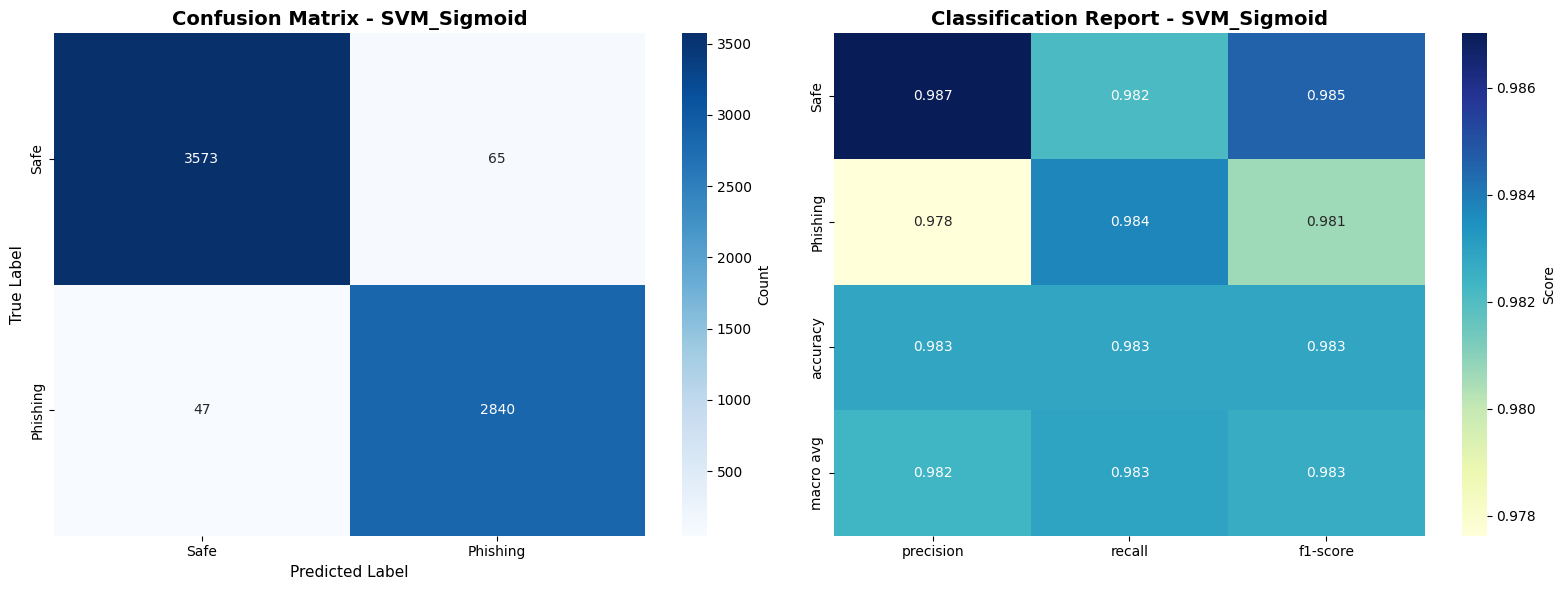


🎯 DETAILED TEST SET METRICS

Model: SVM_Sigmoid

📊 Performance Metrics:
   Accuracy:  0.9828
   Precision: 0.9776
   Recall:    0.9837
   F1 Score:  0.9807
   ROC-AUC:   0.9984
   Avg Precision: 0.9977

📋 Confusion Matrix:
   True Negatives:  3,573
   False Positives: 65
   False Negatives: 47
   True Positives:  2,840

🎯 Additional Metrics:
   Specificity: 0.9821
   False Positive Rate: 0.0179
   False Negative Rate: 0.0163


In [8]:
y_pred = model.predict(x_test)

# Get probabilities for metrics
if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(x_test)[:, 1]
elif hasattr(model, "decision_function"):
    y_proba = model.decision_function(x_test)
else:
    y_proba = None

# Create a figure with 2 subplots
fig = plt.figure(figsize=(16, 6))

# 1. Confusion Matrix
ax1 = plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Safe", "Phishing"], 
            yticklabels=["Safe", "Phishing"],
            cbar_kws={"label": "Count"}, ax=ax1)
ax1.set_title("Confusion Matrix - SVM_Sigmoid", fontsize=14, fontweight="bold")
ax1.set_ylabel("True Label", fontsize=11)
ax1.set_xlabel("Predicted Label", fontsize=11)

# 2. Classification Report Heatmap
ax2 = plt.subplot(1, 2, 2)
report = classification_report(y_test, y_pred, 
                               target_names=["Safe", "Phishing"], 
                               output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :-1].T
sns.heatmap(report_df, annot=True, fmt=".3f", cmap="YlGnBu", 
            cbar_kws={"label": "Score"}, ax=ax2)
ax2.set_title("Classification Report - SVM_Sigmoid", fontsize=14, fontweight="bold")

plt.tight_layout()
fig.savefig("../pictures/ML_evaluation_metrics.png", dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: ../pictures/ML_evaluation_metrics.png")
plt.show()

# Print detailed metrics
print("\n" + "="*60)
print("🎯 DETAILED TEST SET METRICS")
print("="*60)
print(f"\nModel: SVM_Sigmoid")
print(f"\n📊 Performance Metrics:")
print(f"   Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred):.4f}")
print(f"   Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"   F1 Score:  {f1_score(y_test, y_pred):.4f}")

if y_proba is not None:
    print(f"   ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
    print(f"   Avg Precision: {average_precision_score(y_test, y_proba):.4f}")

print(f"\n📋 Confusion Matrix:")
print(f"   True Negatives:  {cm[0, 0]:,}")
print(f"   False Positives: {cm[0, 1]:,}")
print(f"   False Negatives: {cm[1, 0]:,}")
print(f"   True Positives:  {cm[1, 1]:,}")

# Calculate additional metrics
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"\n🎯 Additional Metrics:")
print(f"   Specificity: {specificity:.4f}")
print(f"   False Positive Rate: {fp / (fp + tn):.4f}")
print(f"   False Negative Rate: {fn / (fn + tp):.4f}")
print("="*60)